Temperature not found in filename: 975_275mW source_NaBiF4_0.1sec_Middle Temp _high.txt
Temperature not found in filename: 975_275mW source_NaBiF4_0.1sec__Middle Temp _low.txt
Temperature not found in filename: 975_275mW source_NaBiF4_0.1sec__Middle Temp _middle.txt


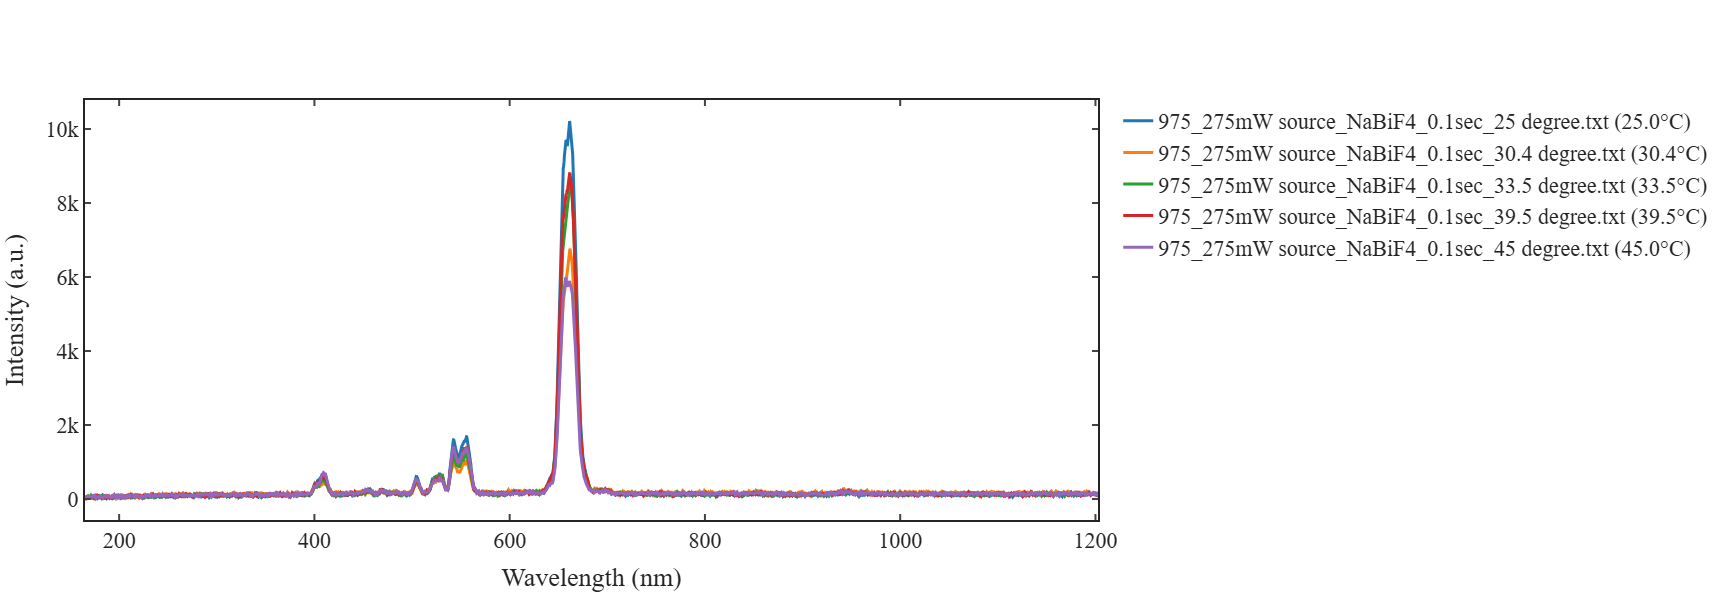


Saved detailed ratio data with temperature to:
D:\Data\2025\september\3 sep\temperature sensing\PL_Intensity_Ratios_with_Temperature.csv
Not enough valid data points to fit model for I_504/I_523
Not enough valid data points to fit model for I_504/I_528
Not enough valid data points to fit model for I_504/I_542
Not enough valid data points to fit model for I_504/I_555
Not enough valid data points to fit model for I_504/I_661
Saved CSV for I_523/I_528: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_523_vs_I_528_vs_Temperature.csv


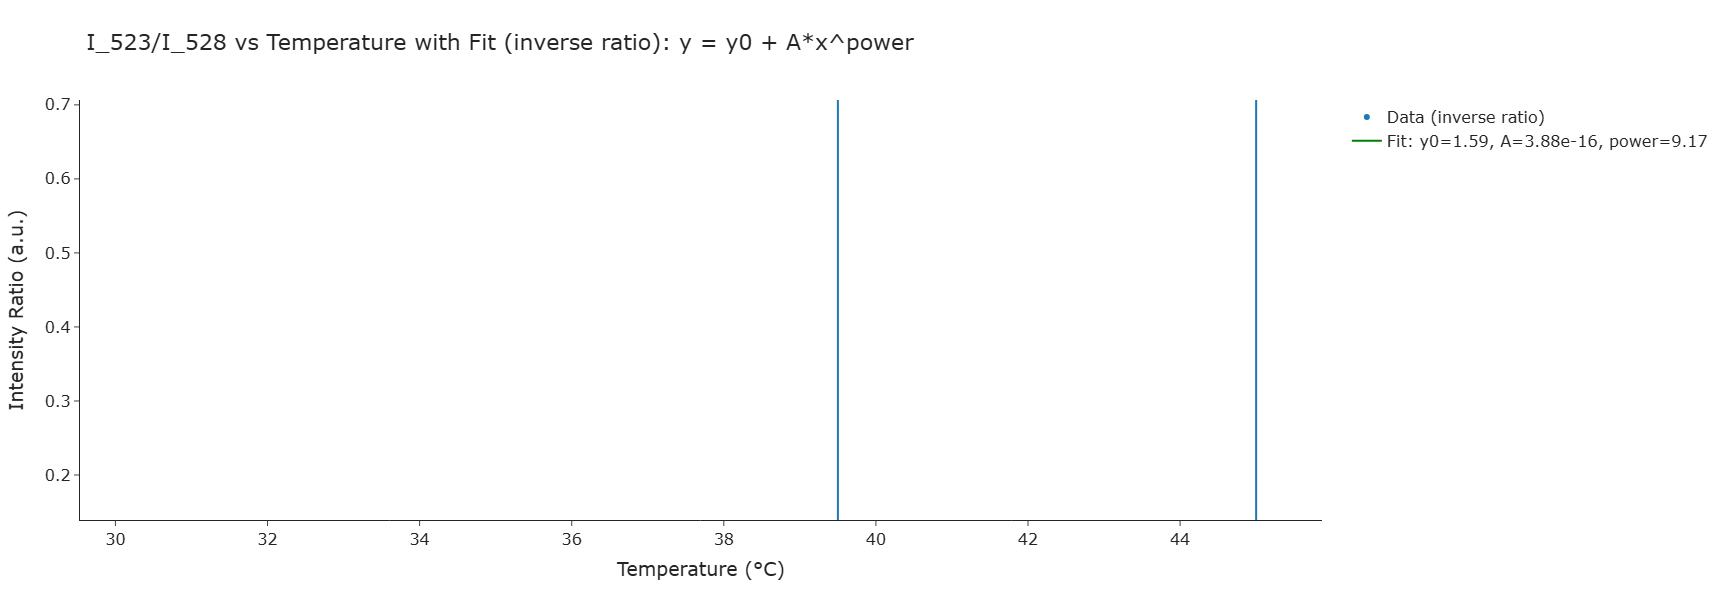

Saved CSV for I_523/I_542: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_523_vs_I_542_vs_Temperature.csv


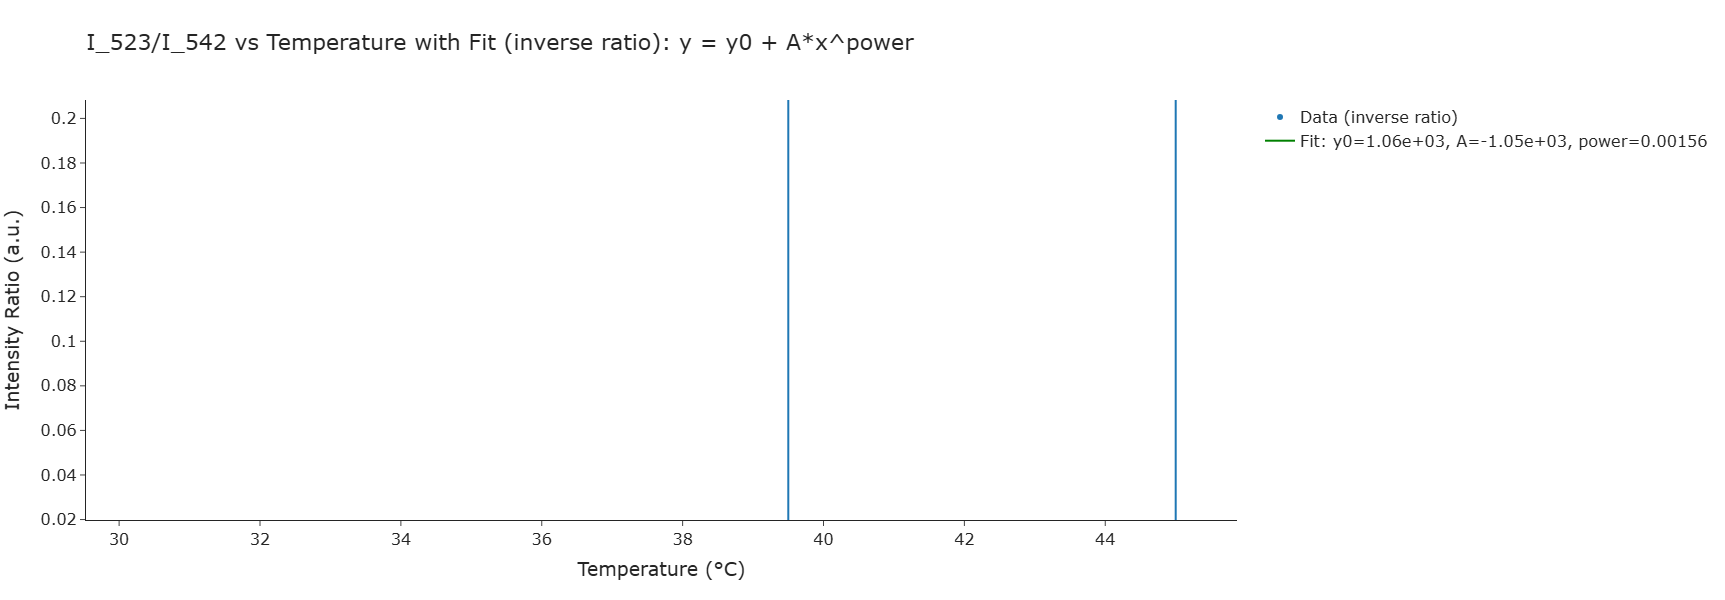

Saved CSV for I_523/I_555: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_523_vs_I_555_vs_Temperature.csv


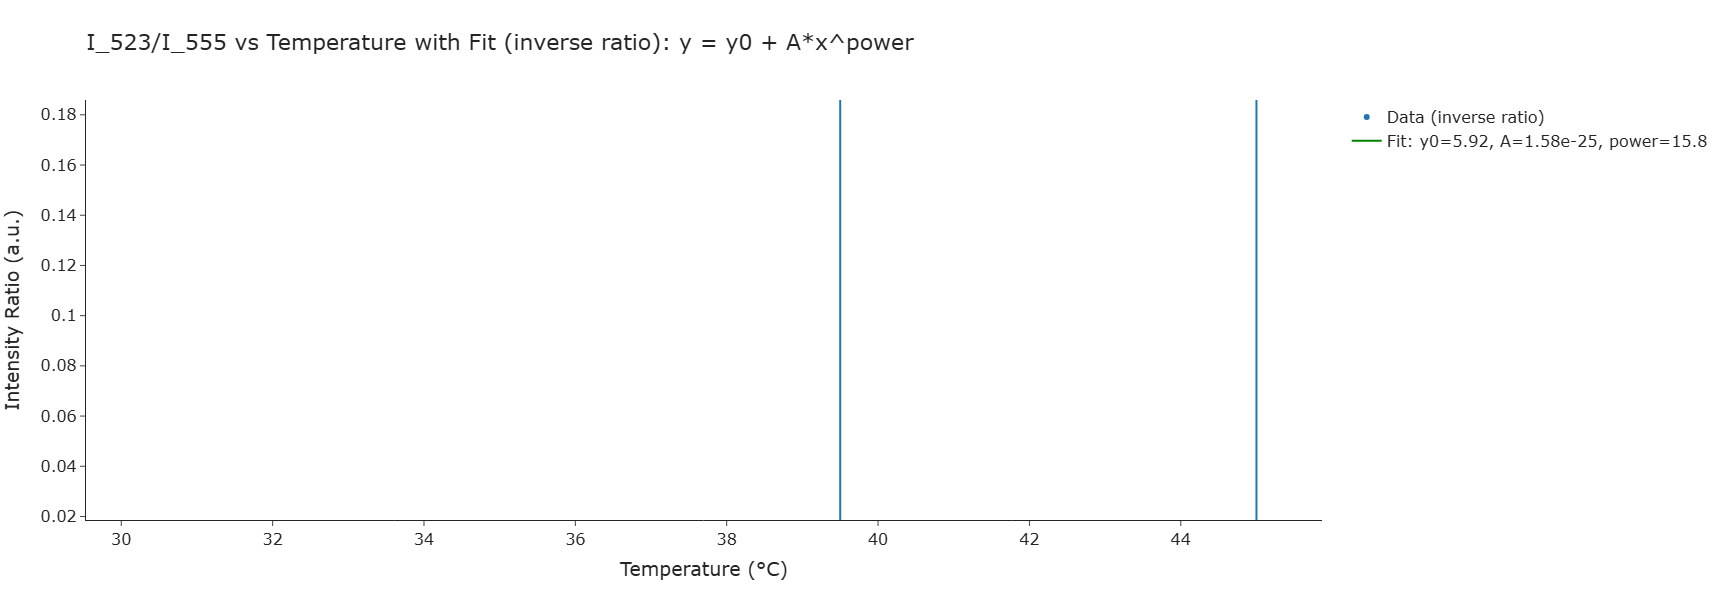

Saved CSV for I_523/I_661: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_523_vs_I_661_vs_Temperature.csv


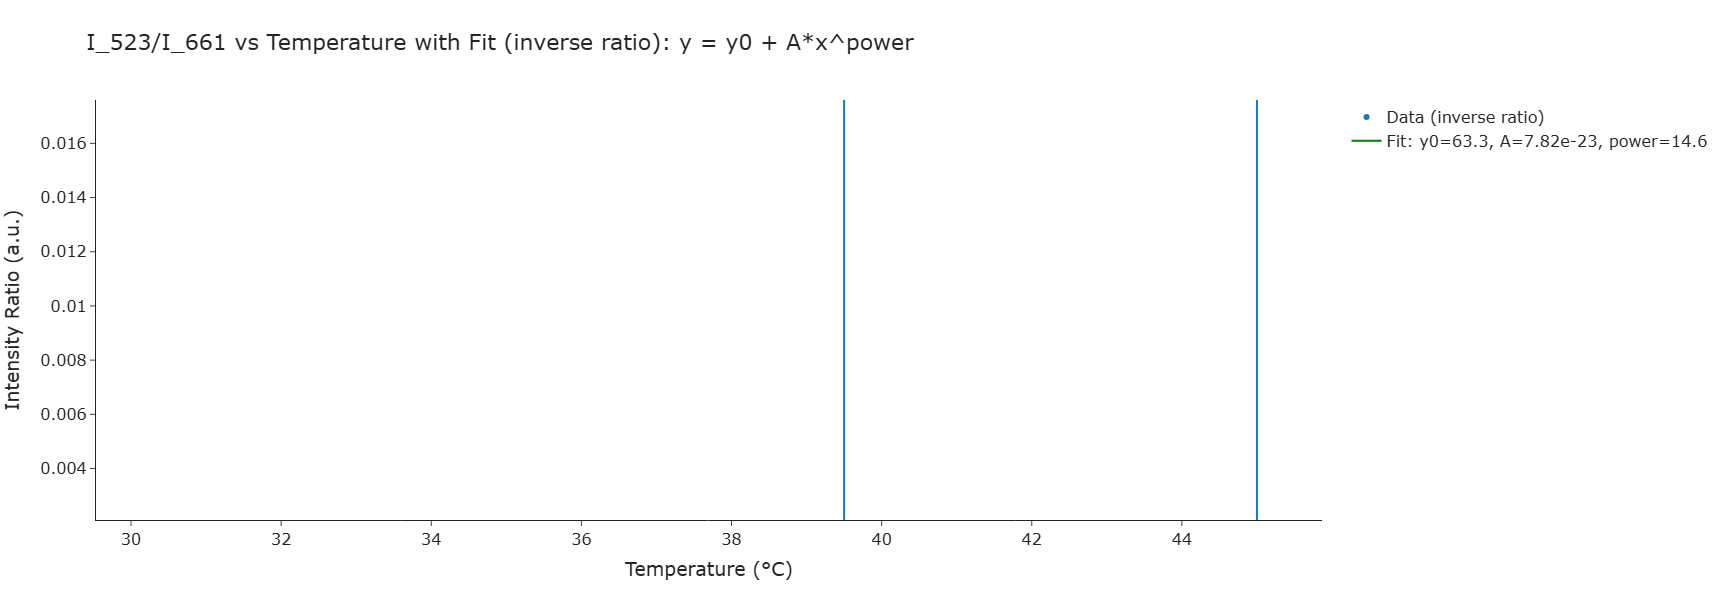

Saved CSV for I_528/I_542: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_528_vs_I_542_vs_Temperature.csv


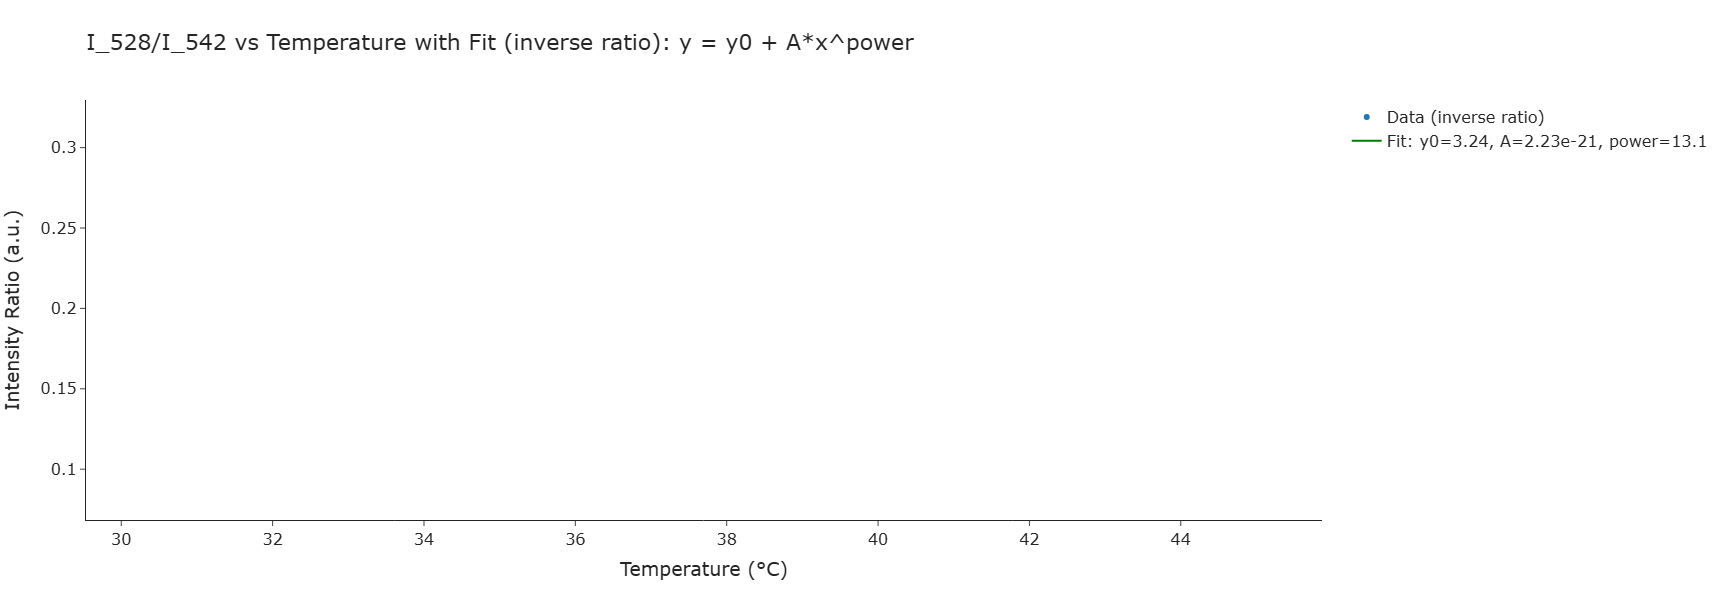

Saved CSV for I_528/I_555: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_528_vs_I_555_vs_Temperature.csv


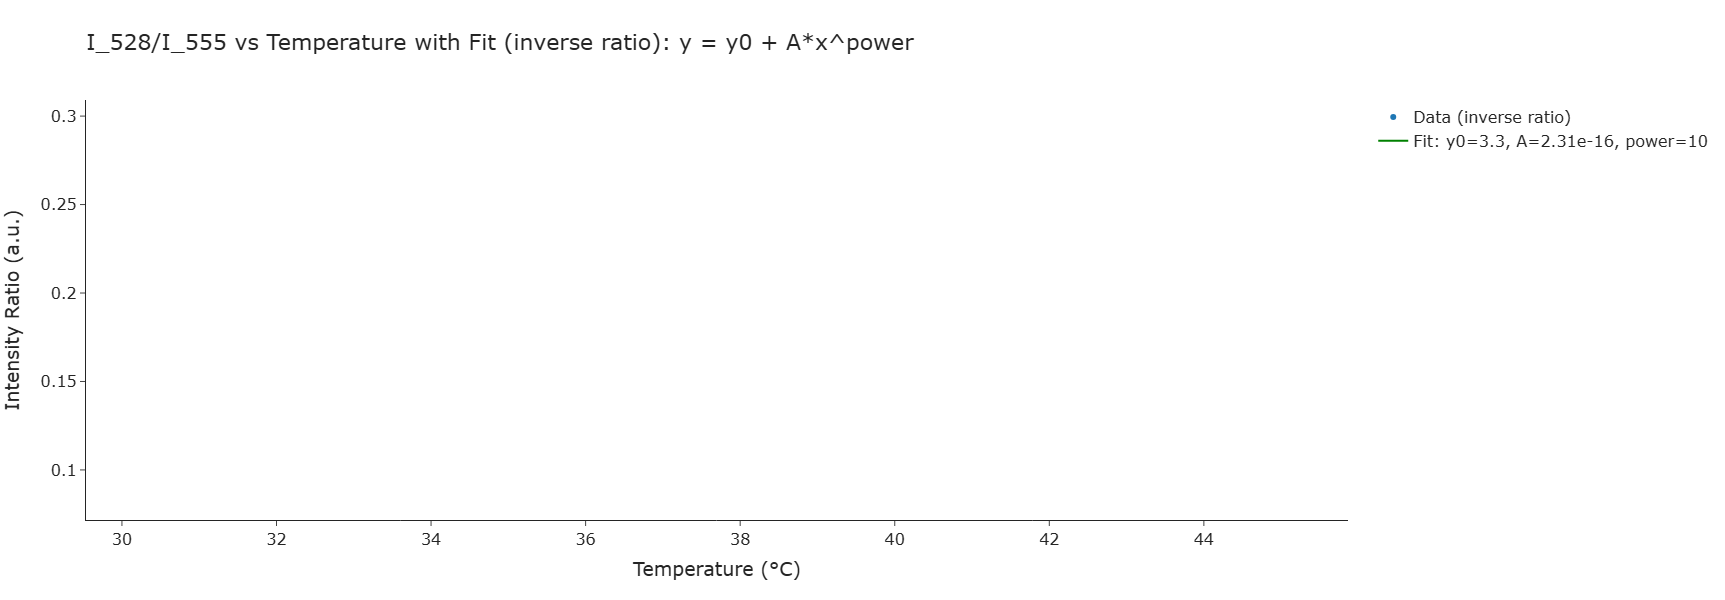

Saved CSV for I_528/I_661: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_528_vs_I_661_vs_Temperature.csv


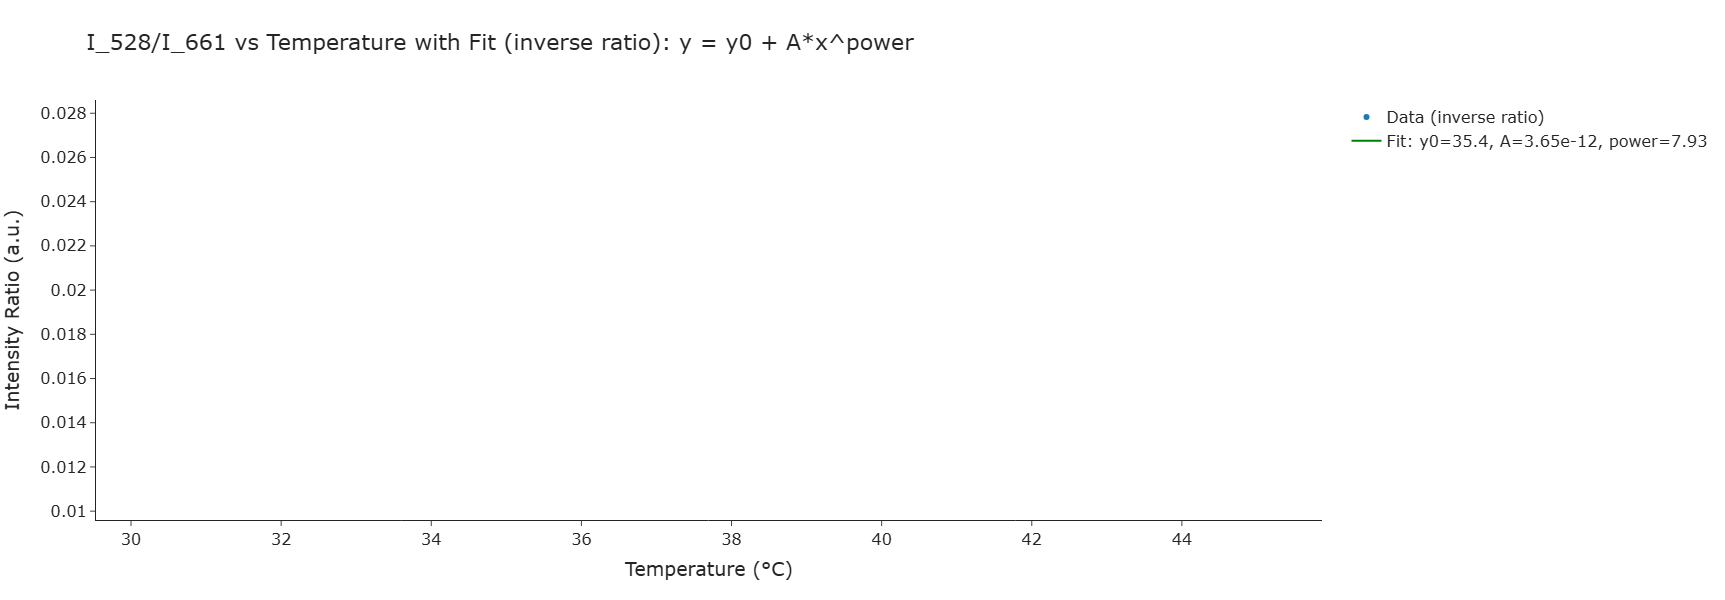

Saved CSV for I_542/I_555: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_542_vs_I_555_vs_Temperature.csv


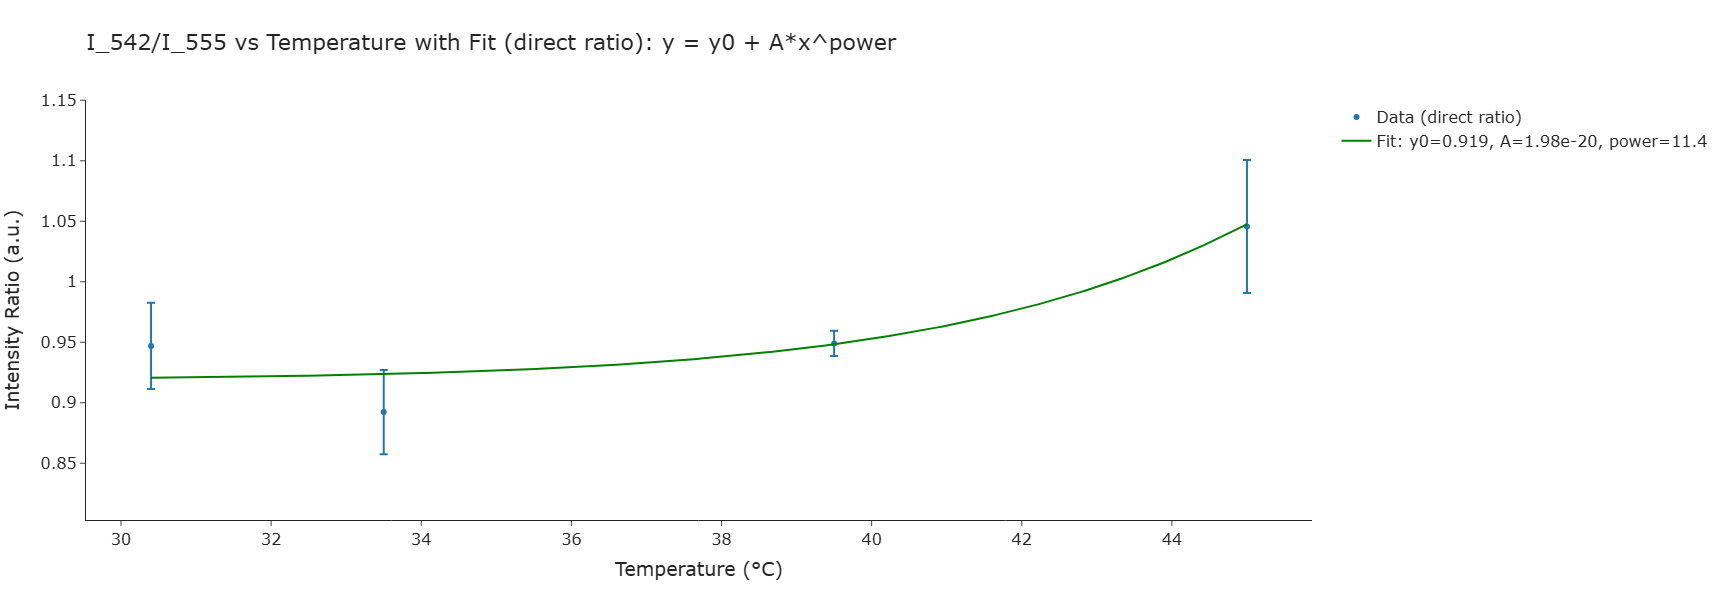

Saved CSV for I_542/I_661: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_542_vs_I_661_vs_Temperature.csv


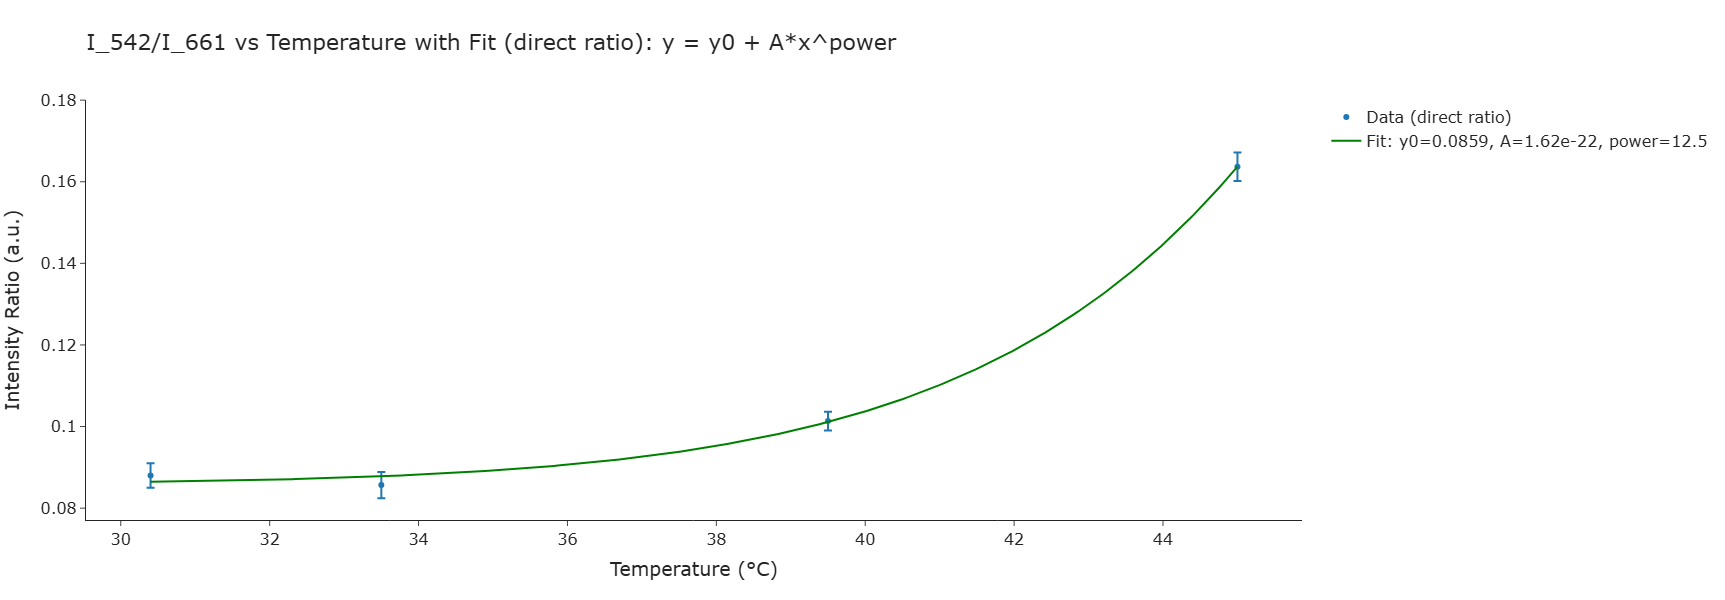

Saved CSV for I_555/I_661: D:\Data\2025\september\3 sep\temperature sensing\PL_Ratio_I_555_vs_I_661_vs_Temperature.csv
Inverse fit did not converge for I_555/I_661: Optimal parameters not found: Number of calls to function has reached maxfev = 10000.


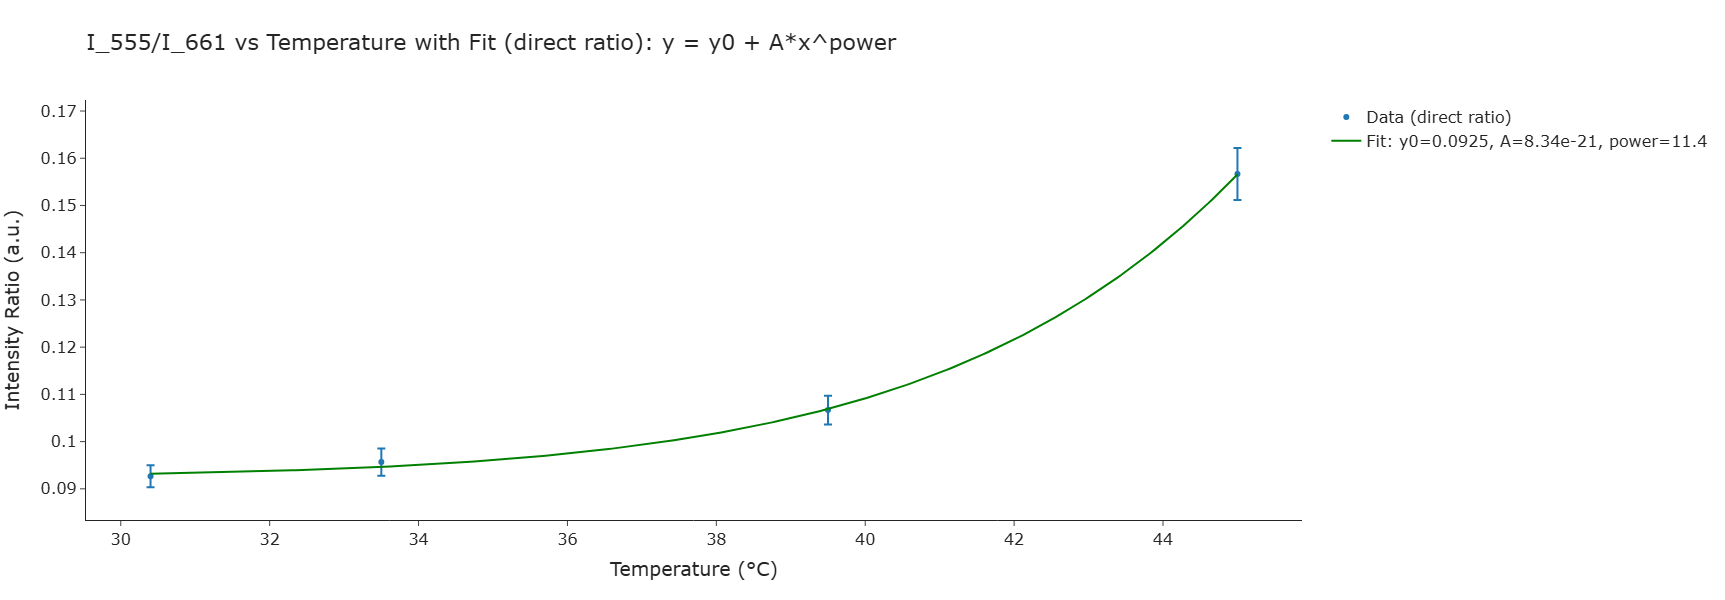


Saved fit parameters and percentage change per degree (including inverse check) to:
D:\Data\2025\september\3 sep\temperature sensing\Fit_Params_and_Percent_Change_with_Inverse_Check.csv

Fit parameters and percentage change per degree per ratio (including direct/inverse fit info):
         Ratio Fit_Type           y0             A      power  \
0  I_523/I_528  inverse     1.585329  3.878802e-16   9.169792   
1  I_523/I_542  inverse  1057.085006 -1.045928e+03   0.001556   
2  I_523/I_555  inverse     5.918255  1.584442e-25  15.771618   
3  I_523/I_661  inverse    63.299632  7.819268e-23  14.555467   
4  I_528/I_542  inverse     3.238146  2.231266e-21  13.097886   
5  I_528/I_555  inverse     3.297108  2.311622e-16  10.045821   
6  I_528/I_661  inverse    35.445134  3.645077e-12   7.929214   
7  I_542/I_555   direct     0.919232  1.975309e-20  11.379669   
8  I_542/I_661   direct     0.085878  1.622854e-22  12.509530   
9  I_555/I_661   direct     0.092457  8.342190e-21  11.423634   

 

In [5]:
import os
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from itertools import combinations
from scipy.optimize import curve_fit

# Define the folder path
folder_path = r"D:\Data\2025\september\3 sep\temperature sensing"

# Plotly template with updated size
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 1000,
    'height': 600,
    'xaxis': {
        'title': 'Wavelength (nm)',
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'title': 'Intensity (a.u.)',
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.0,
        'tickwidth': 2.0,
        'ticklen': 6,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white'
    },
    'font': {
        'family': 'mathjax',
        'size': 22,
    }
}

# Target wavelengths
target_wavelengths = np.array([661, 555, 542, 504, 528, 523])

# Wavelength used for background subtraction before ratio
background_wavelength = 750

# Use combinations (numerator < denominator) to avoid duplicates
ratio_pairs = list(combinations(sorted(target_wavelengths), 2))
ratio_columns = [f'I_{i}/I_{j}' for i, j in ratio_pairs]

# Regex pattern to extract temperature (decimal number before 'degree')
temp_pattern = re.compile(r'(\d+\.?\d*)\s*degree')

# Figure for spectral plots (one spectrum per temperature)
fig = go.Figure(layout=fig_template.layout)
spectra_temps_plotted = set()

results = []

for filename in sorted(os.listdir(folder_path)):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path, filename)
        try:
            # Extract temperature from filename
            temp_match = temp_pattern.search(filename)
            if temp_match:
                temperature = float(temp_match.group(1))
            else:
                print(f"Temperature not found in filename: {filename}")
                continue

            # Load spectral data
            data = np.loadtxt(file_path)
            if data.shape[1] < 2:
                continue

            wavelength = data[:, 0]
            intensity = data[:, 1]

            # Background subtraction: subtract intensity at 750 nm
            intensity_750 = np.interp(background_wavelength, wavelength, intensity)

            # Interpolate intensities at target wavelengths
            interp_intensity = np.interp(target_wavelengths, wavelength, intensity)

            # Subtract background intensity (at 750 nm)
            interp_intensity_bg_subtracted = interp_intensity - intensity_750

            # Make sure no negative values after subtraction (set negatives to zero)
            interp_intensity_bg_subtracted = np.clip(interp_intensity_bg_subtracted, 0, None)

            # Also subtract min intensity to normalize as original code intended
            interp_intensity_bg_subtracted -= interp_intensity_bg_subtracted.min()

            # Plot one spectrum per temperature (plot original intensity minus min for display)
            if temperature not in spectra_temps_plotted:
                intensity_for_plot = intensity - intensity.min()
                fig.add_trace(go.Scatter(x=wavelength, y=intensity_for_plot, mode='lines', name=f"{filename} ({temperature}°C)"))
                spectra_temps_plotted.add(temperature)

            # Calculate ratios using background subtracted intensities
            ratios = []
            for i, j in ratio_pairs:
                i_idx = np.where(target_wavelengths == i)[0][0]
                j_idx = np.where(target_wavelengths == j)[0][0]
                denom = interp_intensity_bg_subtracted[j_idx]
                if denom == 0:
                    ratios.append(np.nan)
                else:
                    ratios.append(interp_intensity_bg_subtracted[i_idx] / denom)

            results.append([filename, temperature] + ratios)

        except Exception as e:
            print(f"Failed to process {filename}: {e}")

# Show spectral plots (one per temperature)
fig.show()

# Create DataFrame from all results (including repeated temperatures)
df = pd.DataFrame(results, columns=['Filename', 'Temperature'] + ratio_columns)
df[ratio_columns] = df[ratio_columns].round(3)

# Save detailed data with duplicates
output_csv_path = os.path.join(folder_path, "PL_Intensity_Ratios_with_Temperature.csv")
df.to_csv(output_csv_path, index=False)
print(f"\nSaved detailed ratio data with temperature to:\n{output_csv_path}")

# Group by temperature and compute mean and std deviation for each ratio
grouped = df.groupby('Temperature')[ratio_columns].agg(['mean', 'std']).reset_index()

# Flatten multiindex columns
grouped.columns = ['Temperature'] + [f"{col}_{stat}" for col, stat in grouped.columns if col != 'Temperature']

# -------------------------------
# Define the model function: y = y0 + A * x^power
def model_func(x, y0, A, power):
    return y0 + A * x ** power

# Function to compute residual sum of squares (weighted by errors)
def rss(y_obs, y_pred, y_err):
    residuals = (y_obs - y_pred) / y_err
    return np.nansum(residuals ** 2)

# Prepare results container for fit parameters and percentage change
fit_results = []

for ratio_col in ratio_columns:
    T = grouped['Temperature'].values
    y = grouped[f'{ratio_col}_mean'].values
    y_err = grouped[f'{ratio_col}_std'].values

    # Filter valid data (remove NaNs and keep T > 0 for power)
    mask = (T > 0) & (~np.isnan(y)) & (~np.isnan(y_err)) & (y_err > 0)
    T_clean = T[mask]
    y_clean = y[mask]
    y_err_clean = y_err[mask]

    if len(T_clean) < 3:
        print(f"Not enough valid data points to fit model for {ratio_col}")
        continue

    # Save this ratio's data as CSV
    ratio_csv_df = pd.DataFrame({
        'Temperature': T_clean,
        f'{ratio_col}_mean': y_clean,
        f'{ratio_col}_std': y_err_clean
    })
    ratio_csv_filename = f"PL_Ratio_{ratio_col.replace('/', '_vs_')}_vs_Temperature.csv"
    ratio_csv_path = os.path.join(folder_path, ratio_csv_filename)
    ratio_csv_df.to_csv(ratio_csv_path, index=False)
    print(f"Saved CSV for {ratio_col}: {ratio_csv_path}")

    # Initial guess for parameters: y0 = min(y), A = (max(y)-min(y)), power = 1
    p0 = [np.min(y_clean), np.max(y_clean) - np.min(y_clean), 1.0]

    best_fit = None
    best_rss = np.inf
    best_fit_label = None  # "direct" or "inverse"
    best_popt = None
    best_pcov = None

    # 1) Try fitting direct ratio y = R
    try:
        popt, pcov = curve_fit(model_func, T_clean, y_clean, sigma=y_err_clean, p0=p0, maxfev=10000)
        y_fit = model_func(T_clean, *popt)
        rss_val = rss(y_clean, y_fit, y_err_clean)
        if rss_val < best_rss:
            best_rss = rss_val
            best_fit = y_fit
            best_fit_label = 'direct'
            best_popt = popt
            best_pcov = pcov
    except RuntimeError as e:
        print(f"Direct fit did not converge for {ratio_col}: {e}")

    # 2) Try fitting inverse ratio y = 1/R
    y_inv = 1 / y_clean
    y_inv_err = y_err_clean / (y_clean**2)  # error propagation for inverse

    # Filter out problematic inverse data (avoid division by zero)
    inv_mask = (~np.isnan(y_inv)) & (~np.isinf(y_inv)) & (y_inv_err > 0)
    T_inv = T_clean[inv_mask]
    y_inv_clean = y_inv[inv_mask]
    y_inv_err_clean = y_inv_err[inv_mask]

    if len(T_inv) >= 3:
        try:
            popt_inv, pcov_inv = curve_fit(model_func, T_inv, y_inv_clean, sigma=y_inv_err_clean, p0=p0, maxfev=10000)
            y_fit_inv = model_func(T_inv, *popt_inv)
            rss_val_inv = rss(y_inv_clean, y_fit_inv, y_inv_err_clean)
            if rss_val_inv < best_rss:
                best_rss = rss_val_inv
                best_fit = y_fit_inv
                best_fit_label = 'inverse'
                best_popt = popt_inv
                best_pcov = pcov_inv
        except RuntimeError as e:
            print(f"Inverse fit did not converge for {ratio_col}: {e}")

    if best_popt is None:
        print(f"No successful fit for {ratio_col}")
        continue

    y0_fit, A_fit, power_fit = best_popt

    # Generate fit values for plotting
    T_fit = np.linspace(min(T_clean), max(T_clean), 300)
    y_fit_plot = model_func(T_fit, *best_popt)

    # Y axis limits with margin
    y_min = max(0, np.min(y_clean) * 0.9)
    y_max = np.max(y_clean) * 1.1

    # Plot data and fit curve
    fig_single = go.Figure(layout=go.Layout(
        title=f'{ratio_col} vs Temperature with Fit ({best_fit_label} ratio): y = y0 + A*x^power',
        xaxis=dict(title='Temperature (°C)'),
        yaxis=dict(title='Intensity Ratio (a.u.)', range=[y_min, y_max]),
        width=1000,
        height=600,
        template='simple_white',
        font=dict(size=16),
    ))

    # Plot the data points depending on which fit was chosen
    if best_fit_label == 'direct':
        fig_single.add_trace(go.Scatter(
            x=T_clean,
            y=y_clean,
            error_y=dict(type='data', array=y_err_clean, visible=True),
            mode='markers',
            name='Data (direct ratio)'
        ))
        fig_single.add_trace(go.Scatter(
            x=T_fit,
            y=y_fit_plot,
            mode='lines',
            line=dict(color='green'),
            name=f'Fit: y0={y0_fit:.3g}, A={A_fit:.3g}, power={power_fit:.3g}'
        ))
    else:
        # Plot inverse ratio data and fit
        fig_single.add_trace(go.Scatter(
            x=T_inv,
            y=y_inv_clean,
            error_y=dict(type='data', array=y_inv_err_clean, visible=True),
            mode='markers',
            name='Data (inverse ratio)'
        ))
        fig_single.add_trace(go.Scatter(
            x=T_fit,
            y=y_fit_plot,
            mode='lines',
            line=dict(color='green'),
            name=f'Fit: y0={y0_fit:.3g}, A={A_fit:.3g}, power={power_fit:.3g}'
        ))

    fig_single.show()

    # Calculate percentage change per degree at mean temperature:
    mean_T = np.mean(T_clean)
    y_at_mean = model_func(mean_T, *best_popt)
    dydx_at_mean = A_fit * power_fit * mean_T ** (power_fit - 1)
    pct_change_per_degree = (dydx_at_mean / y_at_mean) * 100 if y_at_mean != 0 else np.nan

    # Store fit parameters and percentage change along with fit type
    fit_results.append({
        'Ratio': ratio_col,
        'Fit_Type': best_fit_label,
        'y0': y0_fit,
        'A': A_fit,
        'power': power_fit,
        'Pct_Change_per_Degree': pct_change_per_degree,
        'RSS': best_rss
    })

# Create DataFrame summarizing fit parameters and percentage change
fit_df = pd.DataFrame(fit_results)

# Save summary to CSV
fit_params_csv = os.path.join(folder_path, 'Fit_Params_and_Percent_Change_with_Inverse_Check.csv')
fit_df.to_csv(fit_params_csv, index=False)
print(f"\nSaved fit parameters and percentage change per degree (including inverse check) to:\n{fit_params_csv}")

print("\nFit parameters and percentage change per degree per ratio (including direct/inverse fit info):")
print(fit_df)

# --------------------------------------
# Summarize which ratios gave good fits (e.g., RSS < threshold)
rss_threshold = 20  # Adjust this threshold based on your data quality

good_fits = fit_df[fit_df['RSS'] < rss_threshold]

print(f"\nRatios with good fits (RSS < {rss_threshold}):")
if not good_fits.empty:
    for _, row in good_fits.iterrows():
        print(f"- {row['Ratio']}: Fit type = {row['Fit_Type']}, RSS = {row['RSS']:.2f}, Pct Change/°C = {row['Pct_Change_per_Degree']:.3f}%")
else:
    print("No ratios met the RSS threshold for a good fit.")